# Word2Vec: Skip-Gram with Negative Sampling 

A NumPy implementation of the word2vec training loop.

**Dataset:** text8 (Wikipedia extract, ~17 MB)  
**Model:** Skip-Gram with negative sampling  
**Optimization:** Stohastic Gradient Descent with linear learning rate decay

## 1. Imports and Setup

In [1]:
import numpy as np
from collections import Counter
import time

np.random.seed(42)

## 2. Load Data

We use the **text8** dataset — a cleaned Wikipedia extract commonly used for word2vec benchmarks. It contains ~17M words of lowercase English text separated by spaces. We use the first 1M words for a reasonable training time.

In [2]:
MAX_WORDS = 1_000_000
with open("data/text8") as f:
    corpus_raw = f.read().split()[:MAX_WORDS]

print(f"Corpus size: {len(corpus_raw):,} words")
print(f"Sample: {' '.join(corpus_raw[:20])}")

Corpus size: 1,000,000 words
Sample: anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english


## 3. Build Vocabulary and Encode Corpus

We keep the top 10,000 most frequent words. All other words are mapped to a special `<UNK>` token (index 0).

In [3]:
VOCAB_SIZE = 10_000

word_counts = Counter(corpus_raw)
# keeping index 0 for <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 1)

idx2word = ["<UNK>"] + [w for w, _ in most_common]
word2idx = {w: i for i, w in enumerate(idx2word)}

# encoding the corpus as integer array
corpus = np.array([word2idx.get(w, 0) for w in corpus_raw], dtype=np.int32)

#  word counts for subsampling
word_freq = np.zeros(VOCAB_SIZE)
for w, c in word_counts.items():
    if w in word2idx:
        word_freq[word2idx[w]] = c
word_freq /= word_freq.sum()

print(f"Vocabulary size: {VOCAB_SIZE:,}")
print(f"Most common: {idx2word[1:11]}")
print(f"UNK tokens in corpus: {np.sum(corpus == 0):,} ({np.mean(corpus == 0)*100:.1f}%)")

Vocabulary size: 10,000
Most common: ['the', 'of', 'and', 'one', 'in', 'a', 'to', 'zero', 'nine', 'is']
UNK tokens in corpus: 84,949 (8.5%)


## 4. Subsampling of Frequent Words

Very common words like "the", "of", "and" provide little useful signal. Following Mikolov et al. (2013), we randomly discard words with probability depending on their frequency:

$$P_{\text{keep}}(w) = \sqrt{\frac{t}{f(w)}} + \frac{t}{f(w)}$$

where $f(w)$ is the word frequency and $t = 10^{-5}$ is a threshold. 

In [4]:
SUBSAMPLE_T = 1e-5

# computing keep probability for each word
freq_corpus = word_freq[corpus]
# avoid division by zero for UNK token 
with np.errstate(divide="ignore", invalid="ignore"):
    keep_prob = np.sqrt(SUBSAMPLE_T / freq_corpus) + SUBSAMPLE_T / freq_corpus
keep_prob = np.minimum(keep_prob, 1.0)
keep_prob = np.nan_to_num(keep_prob, nan=0.0)  # discard UNK

# randomly discarding frequent words
keep_mask = np.random.rand(len(corpus)) < keep_prob
corpus = corpus[keep_mask]
print(f"Corpus after subsampling: {len(corpus):,} words ({len(corpus)/MAX_WORDS*100:.0f}% of original)")

Corpus after subsampling: 323,143 words (32% of original)


## 5. Negative Sampling Table

For efficient negative sampling, we build a large lookup table. Each word index appears in proportion to its frequency raised to the power 0.75 (Mikolov et al.) to smooth the distribution and slihgtly increase chances of rare words to be sampled as negatives.

In [5]:
TABLE_SIZE = 1_000_000

# noise distribution: freq^0.75, normalized
noise_dist = word_freq ** 0.75
noise_dist[0] = 0  # exclude <UNK> from negatives
noise_dist /= noise_dist.sum()

# building table: each index appears proportional to its noise weight
noise_table = np.zeros(TABLE_SIZE, dtype=np.int32)
cumulative = np.cumsum(noise_dist)
j = 0
for i in range(TABLE_SIZE):
    while j < VOCAB_SIZE - 1 and i / TABLE_SIZE > cumulative[j]:
        j += 1
    noise_table[i] = j

print(f"Noise table built ({TABLE_SIZE:,} entries)")
print(f"Sample negatives: {[idx2word[i] for i in noise_table[np.random.randint(0, TABLE_SIZE, 10)]]}")

Noise table built (1,000,000 entries)
Sample negatives: ['sydney', 'continuous', 'dementia', 'close', 'the', 'costume', 'i', 'members', 'culture', 'thai']


## 6. Hyperparameters and Model Initialization

The model has two embedding matrices:
- **W_in** (V × D): embeddings for center words (input)
- **W_out** (V × D): embeddings for context/negative words (output)

Both are initialized with small uniform random values (`±0.5/D`). Initializing W_out to zeros makes the gradient for W_in zero at the start, slowing convergence, we opt for small random values to avoid this.

After training, we use `W_in` as our word vectors.

In [6]:
EMBED_DIM = 50
WINDOW = 5
NUM_NEG = 5
LR_INITIAL = 0.025
LR_MIN = 0.0001
NUM_EPOCHS = 3

# small uniform initialization for both matrices
# W_out is not zero - grad_v_c is nonzero from first step
W_in = (np.random.rand(VOCAB_SIZE, EMBED_DIM) - 0.5) / EMBED_DIM
W_out = (np.random.rand(VOCAB_SIZE, EMBED_DIM) - 0.5) / EMBED_DIM

print(f"Model parameters: {2 * VOCAB_SIZE * EMBED_DIM:,}")

Model parameters: 1,000,000


## 7. SGNS Objective and Gradients

The Skip-Gram Negative Sampling loss for a center word $c$, true context word $o$, and negative samples $\{n_1, \dots, n_K\}$:

$$J = -\log \sigma(\mathbf{u}_o^\top \mathbf{v}_c) - \sum_{k=1}^{K} \log \sigma(-\mathbf{u}_{n_k}^\top \mathbf{v}_c)$$

where $\sigma(x) = \frac{1}{1 + e^{-x}}$ is the sigmoid, $\mathbf{v}_c$ = `W_in[c]`, and $\mathbf{u}_o$ / $\mathbf{u}_{n_k}$ = `W_out[o]` / `W_out[n_k]`.

Using $\frac{d}{dx}[-\log\sigma(x)] = \sigma(x) - 1$ and the chain rule:

| Parameter | Gradient |
|-----------|----------|
| $\mathbf{v}_c$ | $(\sigma(\mathbf{u}_o^\top \mathbf{v}_c) - 1)\,\mathbf{u}_o + \sum_k (1 - \sigma(-\mathbf{u}_{n_k}^\top \mathbf{v}_c))\,\mathbf{u}_{n_k}$ |
| $\mathbf{u}_o$ | $(\sigma(\mathbf{u}_o^\top \mathbf{v}_c) - 1)\,\mathbf{v}_c$ |
| $\mathbf{u}_{n_k}$ | $(1 - \sigma(-\mathbf{u}_{n_k}^\top \mathbf{v}_c))\,\mathbf{v}_c$ |

For $\mathbf{u}_{n_k}$: from $-\log\sigma(-\mathbf{u}_{n_k}^\top\mathbf{v}_c)$, the derivative $(\sigma(z_k)-1)$ times the chain rule $\frac{\partial z_k}{\partial \mathbf{u}_{n_k}} = -\mathbf{v}_c$ gives $(s_k - 1)(-\mathbf{v}_c) = (1 - s_k)\,\mathbf{v}_c$. The two negatives cancel.

## 8. Core Training Functions

In [7]:
def sigmoid(x):
    """Numerically stable sigmoid."""
    x = np.clip(x, -10, 10)
    return 1.0 / (1.0 + np.exp(-x))


def train_step(center, context, negatives, W_in, W_out, lr):
    """
    One training step: forward pass, loss, gradients, parameter update.

    Args:
        center: index of the center word
        context: index of the positive context word
        negatives: array of negative sample indices
        W_in, W_out: embedding matrices (modified in-place)
        lr: current learning rate

    Returns:
        loss value for this pair
    """
    # forward pass
    v_c = W_in[center] # dimensions (D,)
    u_o = W_out[context] # dimensions (D,)
    u_neg = W_out[negatives] # dimensions (K, D)

    score_pos = sigmoid(np.dot(u_o, v_c)) # scalar
    score_neg = sigmoid(-u_neg @ v_c) # dimensions (K,)

    # loss
    loss = -np.log(score_pos + 1e-7) - np.sum(np.log(score_neg + 1e-7))

    # gradients
    grad_v_c = (score_pos - 1) * u_o + ((1 - score_neg) @ u_neg) # dimensions (D,)
    grad_u_o = (score_pos - 1) * v_c # dimensions (D,)
    grad_u_neg = np.outer(1 - score_neg, v_c) # dimensions (K, D)

    # SGD update 
    W_in[center] -= lr * grad_v_c
    W_out[context] -= lr * grad_u_o
    W_out[negatives] -= lr * grad_u_neg

    return loss

## 9. Training Loop

We iterate through the corpus for 3 epochs. For each center word, we use a random window size between 1 and `WINDOW` as in the original implementation. The learning rate decays linearly from 0.025 to 0.0001.

In [8]:
# estimate total training steps for LR scheduling
avg_window = (1 + WINDOW) / 2
total_steps = int(len(corpus) * avg_window * 2 * NUM_EPOCHS)

# pre-generating random numbers to reduce per-iteration overhead
neg_pool_size = total_steps * NUM_NEG
neg_pool = noise_table[np.random.randint(0, TABLE_SIZE, size=neg_pool_size)]

step = 0
running_loss = 0.0
losses = []
log_every = 100_000

t0 = time.time()
print(f"Training on {len(corpus):,} words, ~{total_steps:,} estimated steps")
print(f"{'Step':>10} {'Loss':>8} {'LR':>10} {'Steps/s':>10}")

for epoch in range(NUM_EPOCHS):
    # pre-generating window sizes for current epoch
    random_windows = np.random.randint(1, WINDOW + 1, size=len(corpus))

    for i in range(len(corpus)):
        center = corpus[i]

        # linear learning rate decay
        lr = max(LR_MIN, LR_INITIAL * (1 - step / total_steps))

        actual_window = random_windows[i]
        start = max(0, i - actual_window)
        end = min(len(corpus), i + actual_window + 1)

        for j in range(start, end):
            if j == i:
                continue
            context = corpus[j]

            negatives = neg_pool[step * NUM_NEG : (step + 1) * NUM_NEG]
            loss = train_step(center, context, negatives, W_in, W_out, lr)

            running_loss += loss
            step += 1
            # logging
            if step % log_every == 0:
                avg_loss = running_loss / log_every
                duration = time.time() - t0
                sps = step / duration
                losses.append(avg_loss)
                print(f"{step:>10,} {avg_loss:>8.4f} {lr:>10.6f} {sps:>10,.0f}")
                running_loss = 0.0

duration = time.time() - t0
print(f"\nCompleted {step:,} steps in {duration:.0f}s ({step/duration:,.0f} steps/s)")

Training on 323,143 words, ~5,816,574 estimated steps
      Step     Loss         LR    Steps/s
   100,000   3.3750   0.024570     12,959
   200,000   2.6888   0.024140     12,906
   300,000   2.4134   0.023711     12,918
   400,000   2.2126   0.023281     13,070
   500,000   2.0862   0.022851     13,033
   600,000   2.1542   0.022421     13,000
   700,000   2.0630   0.021991     12,899
   800,000   2.0544   0.021562     12,750
   900,000   2.0127   0.021132     12,833
 1,000,000   2.0399   0.020702     12,434
 1,100,000   1.9627   0.020272     12,045
 1,200,000   2.0355   0.019842     12,080
 1,300,000   2.0268   0.019413     12,078
 1,400,000   2.0610   0.018983     12,134
 1,500,000   1.9804   0.018553     12,124
 1,600,000   1.9801   0.018123     12,158
 1,700,000   1.9661   0.017693     12,214
 1,800,000   1.9826   0.017263     12,250
 1,900,000   1.8774   0.016834     12,048
 2,000,000   2.0382   0.016404     12,090
 2,100,000   2.1105   0.015974     12,146
 2,200,000   2.0483   

Quick checks:
- the loss decreases as it should
- how similar words are by cosine similarity

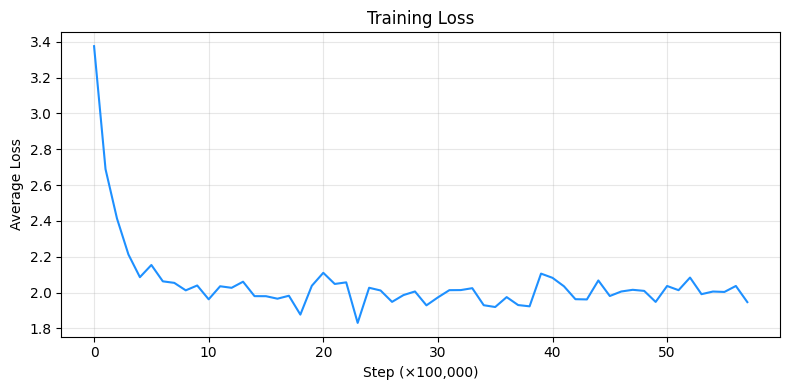

In [9]:
import matplotlib.pyplot as plt

# plotting loss over training
plt.figure(figsize=(8, 4))
plt.plot(losses, color="dodgerblue")
plt.xlabel(f"Step (×{log_every:,})")
plt.ylabel("Average Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
def most_similar(word, top_k=10):
    """Find the top_k most similar words by cosine similarity."""
    if word not in word2idx:
        print(f"'{word}' not in vocabulary")
        return
    idx = word2idx[word]
    v = W_in[idx]
    norms = np.linalg.norm(W_in, axis=1)
    sims = W_in @ v / (norms * np.linalg.norm(v) + 1e-9)
    sims[idx] = -1
    sims[0] = -1
    top_indices = np.argsort(sims)[-top_k:][::-1]
    print(f"Most similar to '{word}':")
    for i in top_indices:
        print(f"  {idx2word[i]:15s} {sims[i]:.4f}")
    print()

for query in ["five", "singer", "german", "people", "god", "year"]:
    most_similar(query, top_k=4)

Most similar to 'five':
  six             0.9778
  three           0.9766
  seven           0.9741
  musician        0.9706

Most similar to 'singer':
  actress         0.9962
  actor           0.9924
  french          0.9852
  laureate        0.9839

Most similar to 'german':
  physicist       0.9918
  poet            0.9916
  politician      0.9909
  laureate        0.9905

Most similar to 'people':
  casualties      0.9870
  germany         0.9855
  die             0.9847
  schopenhauer    0.9818

Most similar to 'god':
  deities         0.9806
  does            0.9649
  decay           0.9648
  radioactive     0.9634

Most similar to 'year':
  don             0.9857
  over            0.9852
  ireland         0.9842
  jack            0.9840



Due to truncation of the training corpus, embedding quality is uneven: some concepts "clustered" semantically (e.g. "five" and other words denominating numbers), others were rather captured in overall textual context (e.g. words similar to "german").